In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [6]:
# Зчитуємо дані з файлу та створюємо DataFrame
data = pd.read_csv('data.txt', delimiter='-', header=None, names=['date', 'production'])
data['date'] = pd.to_datetime(data['date'], format='%d.%m.%Y')
data = data.set_index('date')
data

,production
date,
2019-01-01,15204.1
2019-02-01,13246.7
2019-03-01,13558.0
2019-04-01,11922.8
2019-05-01,11445.8
2019-06-01,11405.2
2019-07-01,11385.8
2019-08-01,11499.5
2019-09-01,11118.0


In [7]:
# Додаємо стовпці з номером місяця та року
data['month'] = data.index.month
data['year'] = data.index.year
data

,production,month,year
date,,,
2019-01-01,15204.1,1,2019
2019-02-01,13246.7,2,2019
2019-03-01,13558.0,3,2019
2019-04-01,11922.8,4,2019
2019-05-01,11445.8,5,2019
2019-06-01,11405.2,6,2019
2019-07-01,11385.8,7,2019
2019-08-01,11499.5,8,2019
2019-09-01,11118.0,9,2019


In [8]:
# Розбиваємо дані на тренд, сезонність та шум
decomp = seasonal_decompose(data['production'], period=12)

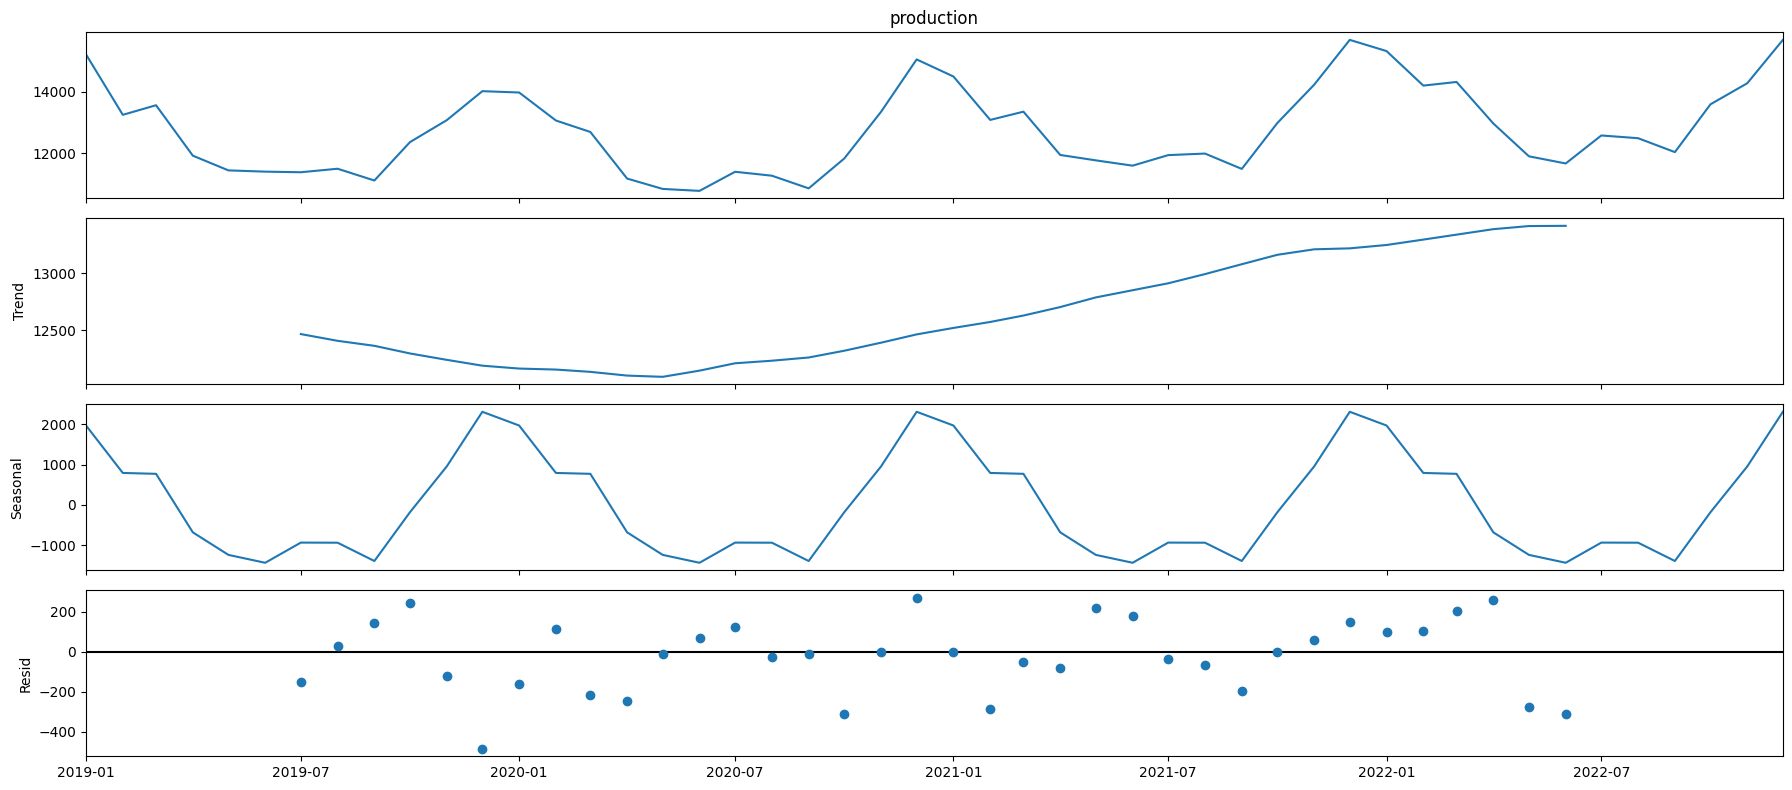

In [9]:
# Перевіримо тенденції та сезонні компоненти даних. Кожен часовий ряд можна розкласти на 3 компоненти: тренд, сезонність, шум. Візуалізуємо розкладений часовий ряд.
from pylab import rcParams
rcParams['figure.figsize'] = 18, 8
decomposition = seasonal_decompose(data['production'], model='additive')
fig = decomposition.plot()
plt.show()

In [10]:
# Як видно з рисунку, у даних є тенденція до зростанняя та річна сезонність (лаг = 12). 
# Також можемо перевірити наявність сезонності, подивившись на графік ACF. 
# Він показує стрибки при значеннях затримки 12, 24, 36 і так далі. 
# Це можна зробити шляхом розрізнення та перевірки за допомогою статистичних тестів, таких як ADF (для тренду) та OSCB (для сезонності).
# Правила для статистичних тестів –
# ADF: якщо p-значення менше критичного значення, ряд є стаціонарним
# OSCB: якщо значення менше 0,64, ряд є стаціонарним
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
       dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

print(adf_test(data['production']))

Results of Dickey-Fuller Test:
Test Statistic                  0.576584
p-value                         0.987024
#Lags Used                     10.000000
Number of Observations Used    37.000000
Critical Value (1%)            -3.620918
Critical Value (5%)            -2.943539
Critical Value (10%)           -2.610400
dtype: float64
None


Results of Dickey-Fuller Test:
Test Statistic                  0.576584
p-value                         0.987024
#Lags Used                     10.000000
Number of Observations Used    37.000000
Critical Value (1%)            -3.620918
Critical Value (5%)            -2.943539
Critical Value (10%)           -2.610400
dtype: float64
None


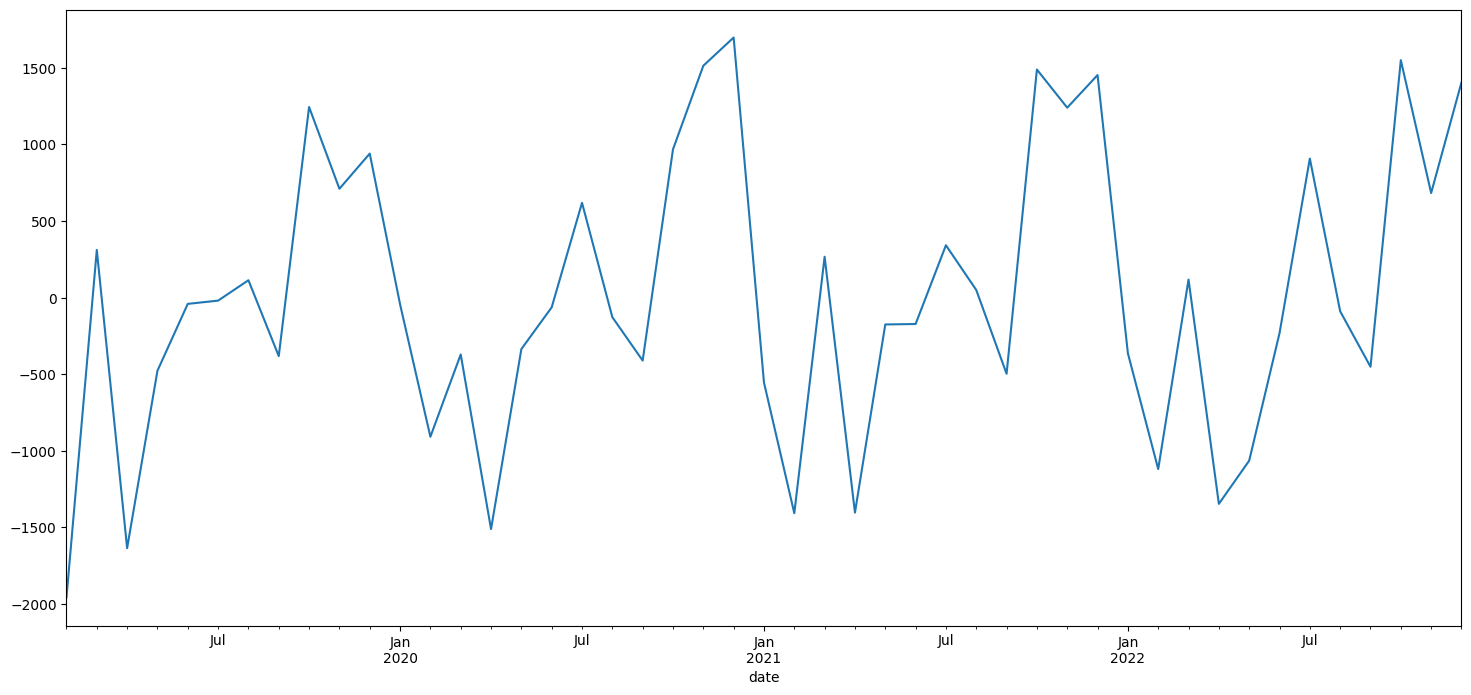

In [11]:
# Після виконання тесту ADF для часового ряду ми отримуємо наступні результати.
# Оскільки p-значення 0,99 більше за критичне значення 0,05, ми можемо статистично підтвердити, що ряд не є стаціонарним. 
# Отже, ми виконаємо розрізнення першого порядку для тренду та повторно запустили тест ADF, щоб перевірити стаціонарність.
ts_t_adj = data['production'] - data['production'].shift(1)
ts_t_adj = ts_t_adj.dropna()
ts_t_adj.plot()

print(adf_test(data['production']))

<Axes: xlabel='date'>

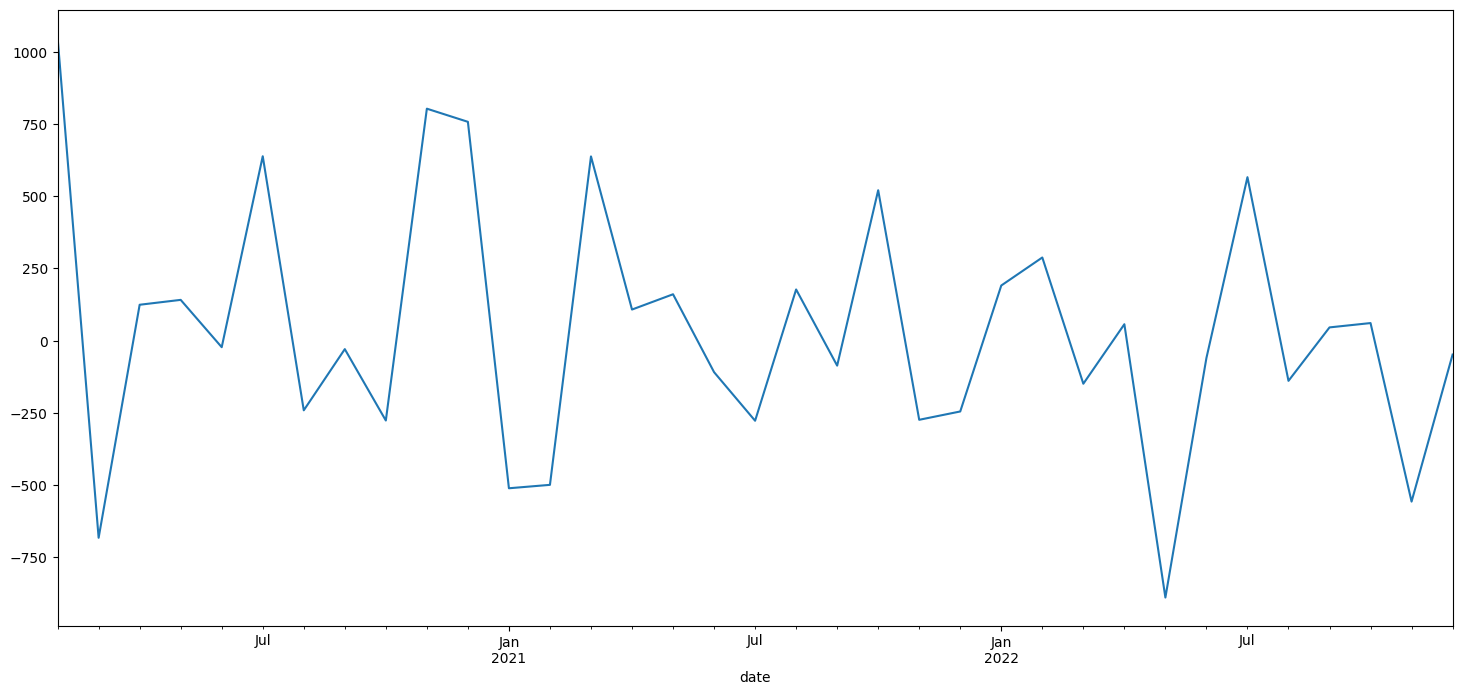

In [12]:
# Тепер ця тенденція, здається, зникла з даних. Виконання тесту ADG підтверджує спостереження. 
# Р-значення менше критичного значення 0,05. Таким чином, ми можемо підтвердити, що тенденція ряду зараз стаціонарна.

# Тепер перейдемо до сезонної різниці. Оскільки дані показують річну сезонність, визначимо різницю з лагом 12, тобто щорічну.

ts_s_adj = ts_t_adj - ts_t_adj.shift(12)
ts_s_adj = ts_s_adj.dropna()
ts_s_adj.plot()

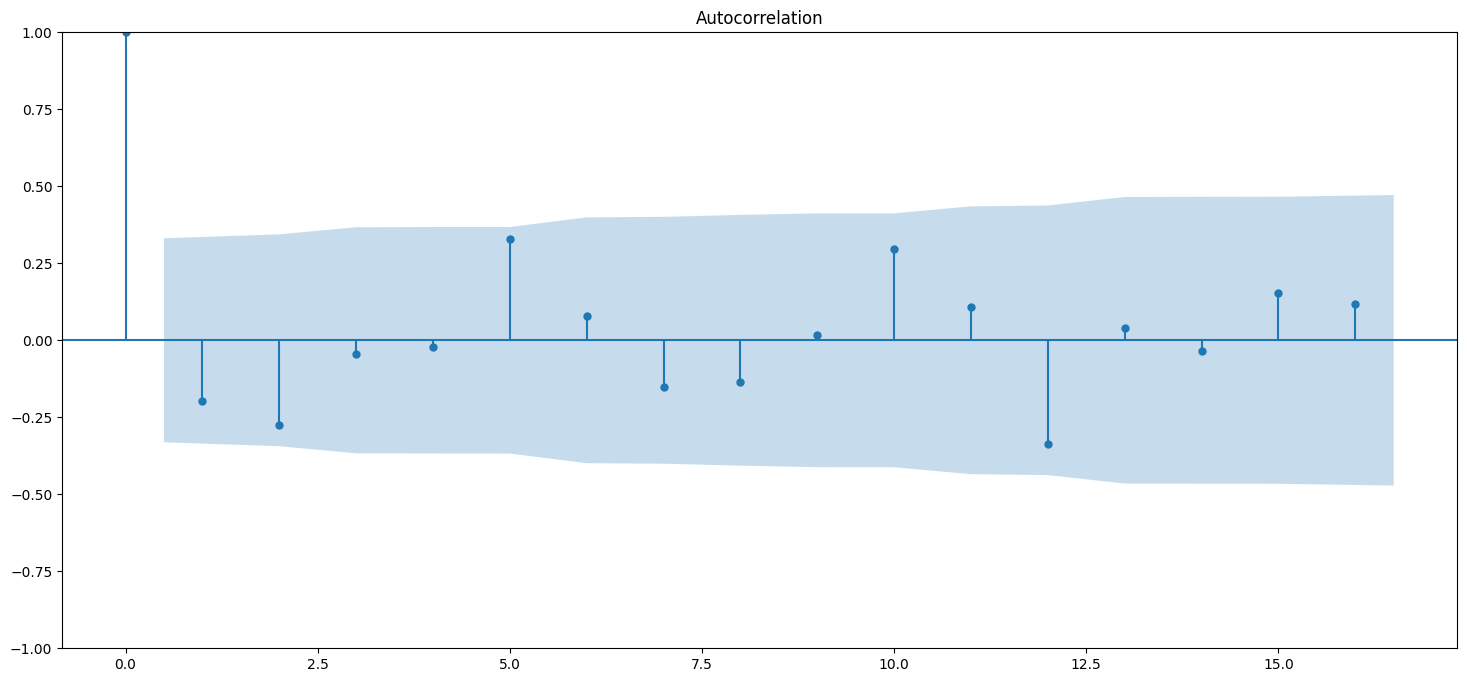

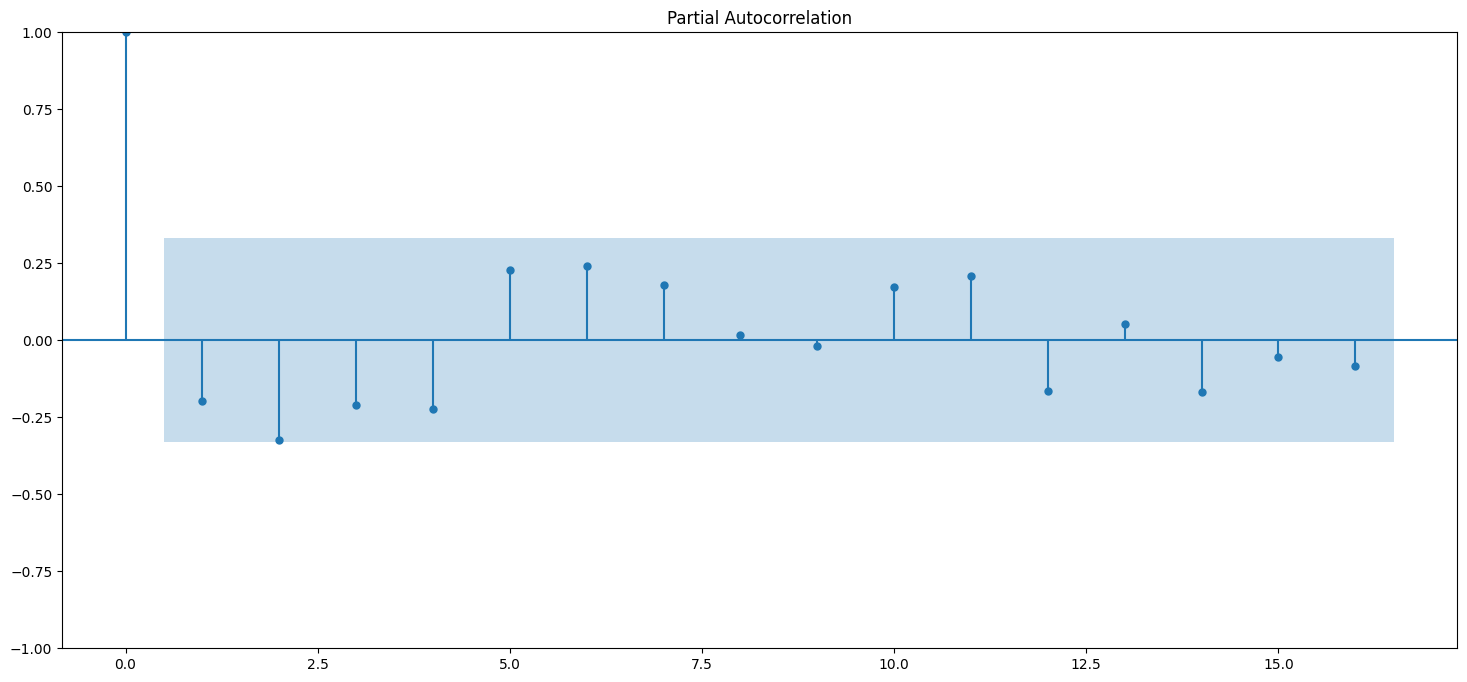

In [13]:
# Визначимо інші компоненти: p, сезонний P, q і сезонний Q. Для цього потрібно буде побудувати графіки ACF і PACF.
# ACF означає функцію автоматичної кореляції, а PACF означає функцію часткової автоматичної кореляції.

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ts_s_adj)
plt.show()
plot_pacf(ts_s_adj)
plt.show()

In [14]:
# Отже, для графіка ACF початкові стрибки з відставанням = 1 і сезонні стрибки з відставанням = 12, що означає ймовірний AR порядок 1 і сезонний AR порядок 1
# Для графіка PACF початкові стрибки з відставанням = 1 і сезонні стрибки з відставанням = 12, що означає ймовірний МА порядок 1 або 2 і сезонний МА порядок 1
# Ймовірне рівняння моделі SARIMA може бути –

# SARIMA(1,1,1)x(1,1,1)12

# Створення моделі
# Оскільки немає впевненості в точному рівнянні моделі, виконаємо пошук у сітці зі списком можливих значень навколо наших оцінених параметрів. 
# Потім ми виберемо модель з найменшим AIC.

import itertools
p = range(0, 3)
d = range(1,2)
q = range(0, 4)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]
print('Examples of parameter combinations for Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
seasonal_pdq

Examples of parameter combinations for Seasonal ARIMA...
SARIMAX: (0, 1, 1) x (0, 1, 1, 12)
SARIMAX: (0, 1, 1) x (0, 1, 2, 12)
SARIMAX: (0, 1, 2) x (0, 1, 3, 12)


[(0, 1, 0, 12),
 (0, 1, 1, 12),
 (0, 1, 2, 12),
 (0, 1, 3, 12),
 (1, 1, 0, 12),
 (1, 1, 1, 12),
 (1, 1, 2, 12),
 (1, 1, 3, 12),
 (2, 1, 0, 12),
 (2, 1, 1, 12),
 (2, 1, 2, 12),
 (2, 1, 3, 12)]

In [ ]:
import pandas as pd
import statsmodels.api as sm

results_list = []

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(ts_s_adj,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            )
            results = mod.fit(method = 'powell')
            # Додаємо результат в список
            results_list.append({
                'ARIMA Order': param,
                'Seasonal Order': param_seasonal,
                'AIC': results.aic
            })
        except:
            continue

results_df = pd.DataFrame(results_list)

print(results_df)



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

Optimization terminated successfully.
         Current function value: 5.308501
         Iterations: 2
         Function evaluations: 32
Optimization terminated successfully.
         Current function value: 5.145980
         Iterations: 5
         Function evaluations: 125
Optimization terminated successfully.
         Current function value: 5.102996
         Iterations: 4
         Function evaluations: 142


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Optimization terminated successfully.
         Current function value: 5.100012
         Iterations: 3
         Function evaluations: 138
Optimization terminated successfully.
         Current function value: 5.095680
         Iterations: 3
         Function evaluations: 71


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

...

Optimization terminated successfully.
         Current function value: 4.746226
         Iterations: 7
         Function evaluations: 790


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances

Optimization terminated successfully.
         Current function value: 4.755819
         Iterations: 10
         Function evaluations: 1178


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances

Optimization terminated successfully.
         Current function value: 4.757606
         Iterations: 11
         Function evaluations: 1337
    ARIMA Order Seasonal Order         AIC
0     (0, 1, 0)  (0, 1, 0, 12)  373.595073
1     (0, 1, 0)  (0, 1, 1, 12)  364.218591
2     (0, 1, 0)  (0, 1, 2, 12)  363.209701
3     (0, 1, 0)  (0, 1, 3, 12)  365.000844
4     (0, 1, 0)  (1, 1, 0, 12)  360.697632
..          ...            ...         ...
139   (2, 1, 3)  (1, 1, 3, 12)  354.845394
140   (2, 1, 3)  (2, 1, 0, 12)  348.291164
141   (2, 1, 3)  (2, 1, 1, 12)  350.235841
142   (2, 1, 3)  (2, 1, 2, 12)  352.907351
143   (2, 1, 3)  (2, 1, 3, 12)  355.032443

[144 rows x 3 columns]


In [ ]:
# результат в файл CSV
results_df.to_csv('sarima_results.csv', index=False)

In [ ]:

results_df = pd.read_csv('sarima_results.csv')

# Вибір моделі з найменшим значенням AIC
best_model = results_df.loc[results_df['AIC'].idxmin()]


print(f"Найкраща модель: ARIMA{best_model['ARIMA Order']} x {best_model['Seasonal Order']}12")
print(f"AIC: {best_model['AIC']}")


Найкраща модель: ARIMA(2, 1, 2) x (2, 1, 0, 12)12
AIC: 342.55026846801394


In [ ]:
# ARIMA(2, 1, 2)x(2, 1, 0, 12)12 - AIC:342.55026846801394

# Отримавши моделі порядків із пошукової сітки вище, адаптуємо модель SARIMA до наших даних.
mod = SARIMAX(ts_s_adj,
                                order=(2, 1, 2),
                                seasonal_order=(2, 1, 0, 12))
results = mod.fit(method = 'powell')
print(results.summary().tables[1])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances

Optimization terminated successfully.
         Current function value: 4.693575
         Iterations: 12
         Function evaluations: 994
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0550      0.436      0.126      0.900      -0.799       0.909
ar.L2         -0.5599      0.355     -1.577      0.115      -1.256       0.136
ma.L1         -2.0000      6.526     -0.306      0.759     -14.791      10.791
ma.L2          1.0000      6.564      0.152      0.879     -11.865      13.865
ar.S.L12      -1.1693      0.356     -3.281      0.001      -1.868      -0.471
ar.S.L24      -0.9593      0.270     -3.548      0.000      -1.489      -0.429
sigma2      1.126e+04      0.001   9.69e+06      0.000    1.13e+04    1.13e+04


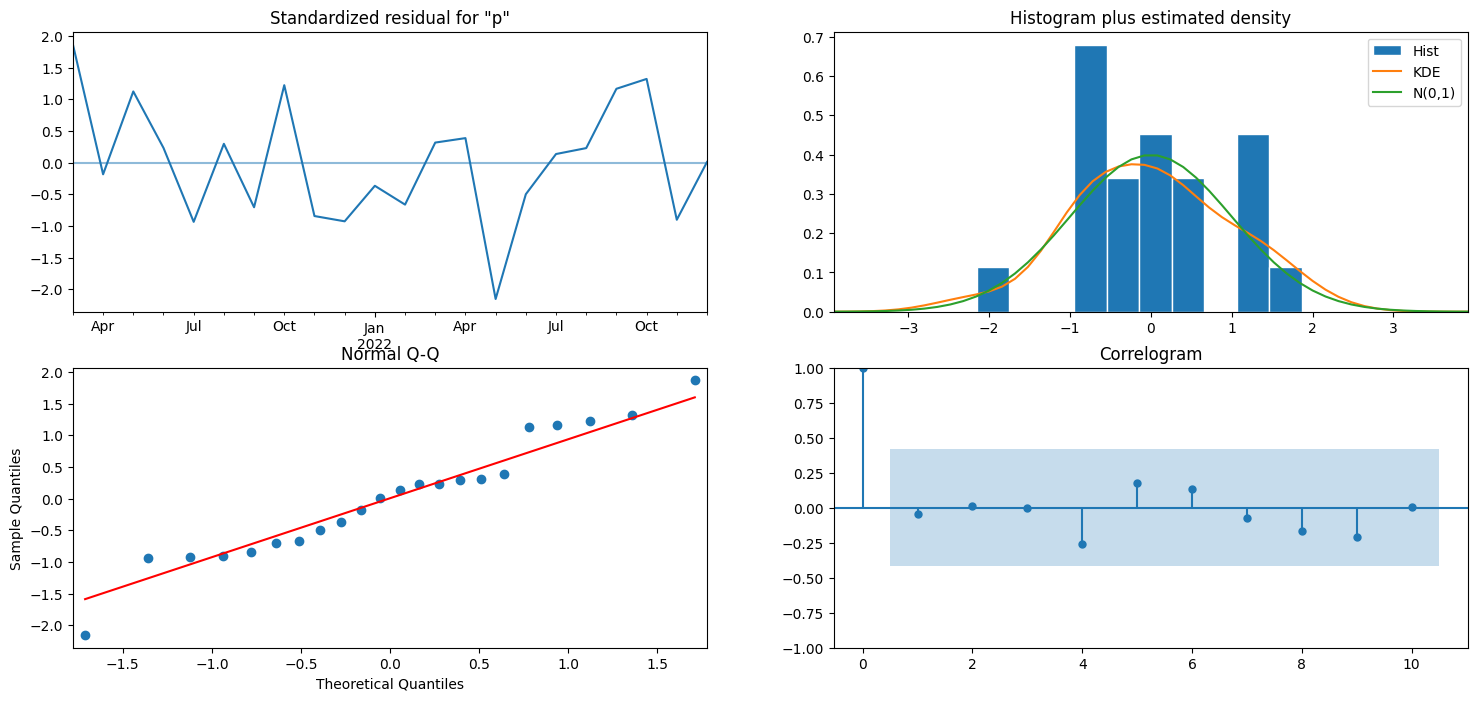

In [17]:
# Після того, як підібрана модель до даних, необхідно перевірити залишкові графіки, 
# щоб перевірити достовірність підгонки моделі. Хороший метод прогнозування дасть залишки з такими властивостями:
# -Залишки некорельовані. Якщо між залишками є кореляції, то в залишках залишається інформація, яку слід використовувати в обчисленні прогнозів.
# -Залишки мають нульове середнє. Якщо залишки мають середнє значення, відмінне від нуля, то прогнози є зміщеними.
results.plot_diagnostics(figsize=(18, 8))
plt.show()

In [18]:
# Створюємо SARIMA модель з оптимальними параметрами
# model = SARIMAX(data['production'], order=(1,1,1), seasonal_order=(1,1,1,12)).fit()
model = SARIMAX(data['production'], order=(2,1,2), seasonal_order=(2,1,0,12)).fit()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
# Прогнозуємо виробництво електроенергії на 2023 рік
forecast = model.forecast(steps=12)

In [20]:
# Зберігаємо прогнозовані дані у файл
with open('forecast.txt', 'w') as file:
    for i, value in enumerate(forecast):
        date = pd.to_datetime('2023-{}-01'.format(i+1)).strftime('%d.%m.%Y')
        file.write('{}-{}\n'.format(date, value))

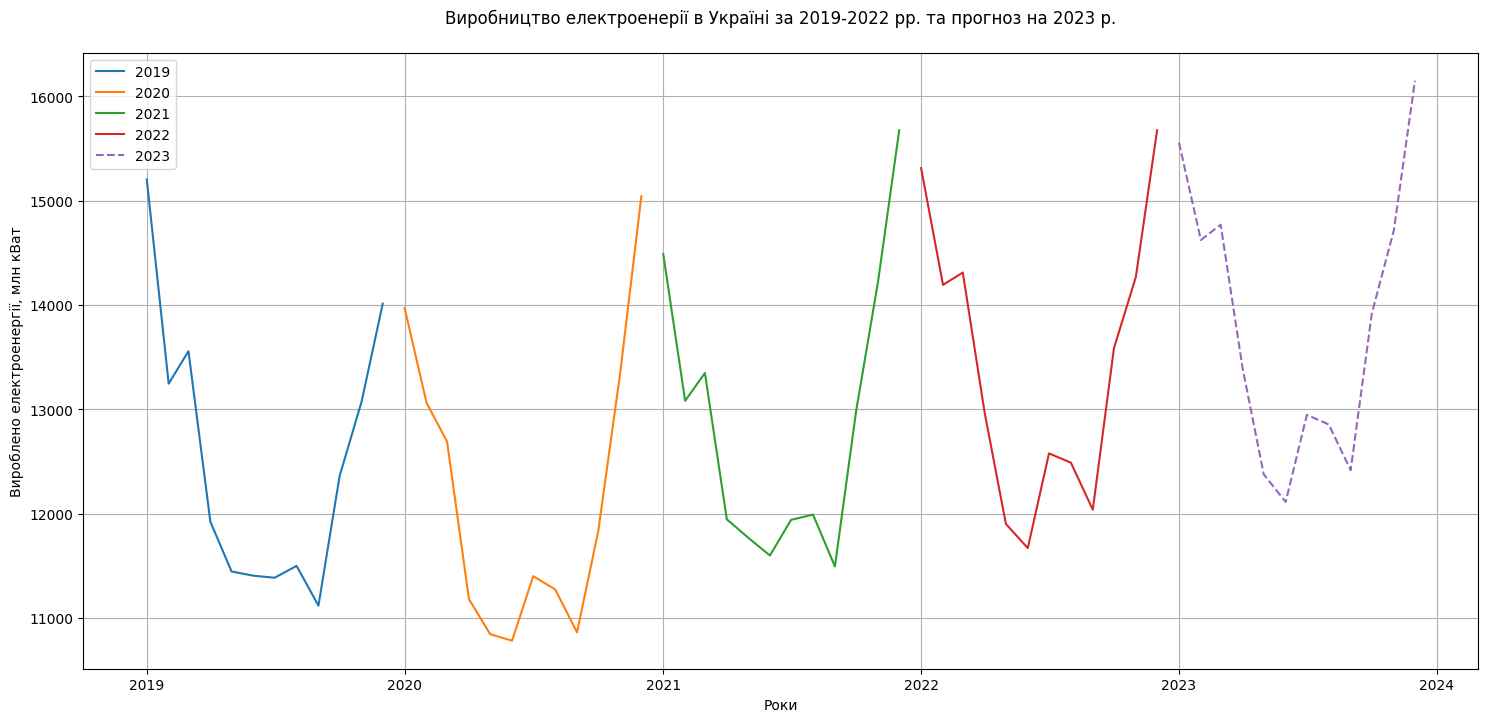

In [21]:
# Робимо графік
plt.title("Виробництво електроенерії в Україні за 2019-2022 рр. та прогноз на 2023 р.\n")
plt.xlabel("Роки")
plt.ylabel("Вироблено електроенергії, млн кВат")
plt.grid()
plt.plot(data['production'][:12], label='2019')
plt.plot(data['production'][12:24], label='2020')
plt.plot(data['production'][24:36], label='2021')
plt.plot(data['production'][36:48], label='2022')
plt.plot(forecast, label='2023', linestyle = 'dashed')
plt.legend()
plt.show()